# Face Recognition with FaceNet

This notebook builds a face-recognition and face-verification workflow using:

- a small image dataset, which I created by collecting images for public figures and for myself;
- a pretrained FaceNet model for 128-dimensional face embeddings;
- a linear support vector machine classifier (SVM) for the known identities;
- cosine similarity for face verification.

## 1. Configuration

In [1]:
from pathlib import Path

WORKING_DIR = Path("/kaggle/working")
DATA_DIR = WORKING_DIR / "data"
OUTPUT_DIR = WORKING_DIR / "outputs"

RANDOM_STATE = 42
TEST_SIZE = 0.20

DATA_DIR.mkdir(parents=True, exist_ok=True)
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

print("Working directory:", WORKING_DIR)
print("Output directory:", OUTPUT_DIR)

Working directory: /kaggle/working
Output directory: /kaggle/working/outputs


## 2. Imports

In [2]:
import json
import math
import shutil

import cv2
import h5py
import matplotlib.pyplot as plt
import numpy as np
import tensorflow as tf

from sklearn.metrics import (
    ConfusionMatrixDisplay,
    accuracy_score,
    balanced_accuracy_score,
    confusion_matrix,
    roc_curve,
)
from sklearn.model_selection import (
    RepeatedStratifiedKFold,
    cross_val_score,
    train_test_split,
)
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import Normalizer
from sklearn.svm import SVC

## 3. Locate the Kaggle inputs

In [3]:
INPUT_ROOT = Path("/kaggle/input")

DATASET_DIR = next(
    path
    for path in INPUT_ROOT.rglob("img_dataset")
    if path.is_dir()
)

FACENET_PATH = next(
    path
    for path in INPUT_ROOT.rglob("facenet_keras.h5")
    if path.is_file()
)

print("Dataset directory:", DATASET_DIR)
print("FaceNet model:", FACENET_PATH)

Dataset directory: /kaggle/input/datasets/marioyouchia/face-recognition-dataset-with-facenet/img_dataset
FaceNet model: /kaggle/input/datasets/suicaokhoailang/facenet-keras/facenet_keras.h5


## 4. Audit the dataset

In [4]:
SUPPORTED_EXTENSIONS = {".jpg", ".jpeg", ".png"}

class_files = {
    folder.name: sorted(
        path
        for path in folder.iterdir()
        if path.is_file()
        and path.suffix.lower() in SUPPORTED_EXTENSIONS
    )
    for folder in sorted(DATASET_DIR.iterdir())
    if folder.is_dir()
}

class_files = {
    label: files
    for label, files in class_files.items()
    if files
}

total_images = sum(
    len(files)
    for files in class_files.values()
)

print(f"Identities: {len(class_files)}")
print(f"Images: {total_images}\n")

for label, files in class_files.items():
    print(f"{label}: {len(files)}")

Identities: 11
Images: 111

Barack Obama: 10
Colin_Powell: 10
Donald Trump: 10
Donald_Rumsfeld: 10
George_W_Bush: 10
Gerhard_Schroeder: 10
Hugo_Chavez: 10
Jacques_Chirac: 10
Mario: 11
Tony_Blair: 10
Vladimir_Putin: 10


## 5. Face preprocessing and train/test split

In [5]:
face_cascade = cv2.CascadeClassifier(
    cv2.data.haarcascades + "haarcascade_frontalface_default.xml"
)


def prepare_face(path, required_size=(160, 160)):
    bgr = cv2.imread(str(path))

    if bgr is None:
        raise ValueError(f"Unreadable image: {path}")

    rgb = cv2.cvtColor(bgr, cv2.COLOR_BGR2RGB)
    gray = cv2.cvtColor(bgr, cv2.COLOR_BGR2GRAY)

    detections = face_cascade.detectMultiScale(
        gray,
        scaleFactor=1.1,
        minNeighbors=4,
        minSize=(30, 30),
    )

    height, width = rgb.shape[:2]

    if len(detections):
        x, y, face_width, face_height = max(
            detections,
            key=lambda box: box[2] * box[3],
        )

        margin = int(max(face_width, face_height) * 0.28)
        center_x = x + face_width // 2
        center_y = y + face_height // 2
        side = min(
            max(face_width, face_height) + 2 * margin,
            width,
            height,
        )

        left = max(0, min(width - side, center_x - side // 2))
        top = max(0, min(height - side, center_y - side // 2))
        crop = rgb[top:top + side, left:left + side]

    else:
        side = min(width, height)
        left = (width - side) // 2
        top = (height - side) // 2
        crop = rgb[top:top + side, left:left + side]

    return cv2.resize(
        crop,
        required_size,
        interpolation=cv2.INTER_AREA,
    ).astype(np.uint8)


image_paths = []
image_labels = []

for label, files in class_files.items():
    image_paths.extend(files)
    image_labels.extend([label] * len(files))

faces = np.stack([
    prepare_face(path)
    for path in image_paths
])

labels = np.asarray(image_labels)
indices = np.arange(len(image_paths))

train_indices, test_indices = train_test_split(
    indices,
    test_size=TEST_SIZE,
    random_state=RANDOM_STATE,
    stratify=labels,
)

train_indices = np.sort(train_indices)
test_indices = np.sort(test_indices)

train_faces = faces[train_indices]
train_labels = labels[train_indices]
train_paths = np.asarray(image_paths, dtype=object)[train_indices]

test_faces = faces[test_indices]
test_labels = labels[test_indices]
test_paths = np.asarray(image_paths, dtype=object)[test_indices]

print("Training faces:", train_faces.shape)
print("Test faces:    ", test_faces.shape)
print("Training labels:", train_labels.shape)
print("Test labels:    ", test_labels.shape)

Training faces: (88, 160, 160, 3)
Test faces:     (23, 160, 160, 3)
Training labels: (88,)
Test labels:     (23,)


## 6. Load the legacy FaceNet model

The attached `facenet_keras.h5` file contains legacy serialized Lambda layers that are incompatible with current Python/Keras versions. So, the following cell copies the Kaggle input to `/kaggle/working`, replaces only the legacy residual scaling layers with an equivalent serializable layer, and then loads the original pretrained weights.

In [6]:
PATCHED_FACENET_PATH = WORKING_DIR / "facenet_keras_patched.h5"

shutil.copy2(
    FACENET_PATH,
    PATCHED_FACENET_PATH,
)


@tf.keras.utils.register_keras_serializable(package="LegacyFaceNet")
class ScaleSum(tf.keras.layers.Layer):
    def __init__(self, scale=1.0, **kwargs):
        super().__init__(**kwargs)
        self.scale = float(scale)

    def call(self, inputs):
        return inputs[0] + self.scale * inputs[1]

    def compute_output_shape(self, input_shape):
        return input_shape[0]

    def get_config(self):
        return {
            **super().get_config(),
            "scale": self.scale,
        }


with h5py.File(PATCHED_FACENET_PATH, "r+") as h5_file:
    model_config = h5_file.attrs["model_config"]

    if isinstance(model_config, bytes):
        model_config = model_config.decode("utf-8")

    model_config = json.loads(model_config)

    for layer in model_config["config"]["layers"]:
        if (
            layer.get("class_name") == "Lambda"
            and "ScaleSum" in layer["config"].get("name", "")
        ):
            old_config = layer["config"]

            layer["class_name"] = "ScaleSum"
            layer["config"] = {
                "name": old_config["name"],
                "trainable": old_config.get("trainable", True),
                "dtype": old_config.get("dtype", "float32"),
                "scale": old_config.get("arguments", {}).get(
                    "scale",
                    1.0,
                ),
            }

    h5_file.attrs.modify(
        "model_config",
        json.dumps(model_config).encode("utf-8"),
    )


facenet_model = tf.keras.models.load_model(
    PATCHED_FACENET_PATH,
    custom_objects={
        "ScaleSum": ScaleSum,
        "LegacyFaceNet>ScaleSum": ScaleSum,
    },
    compile=False,
    safe_mode=False,
)

print("Input shape:", facenet_model.input_shape)
print("Output shape:", facenet_model.output_shape)

2026-07-02 11:05:29.581504: E external/local_xla/xla/stream_executor/cuda/cuda_platform.cc:51] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


Input shape: (None, 160, 160, 3)
Output shape: (None, 128)


## 7. Generate FaceNet embeddings

In [7]:
def standardize_faces(face_batch):
    face_batch = face_batch.astype("float32")
    mean = face_batch.mean(axis=(1, 2, 3), keepdims=True)
    std = np.maximum(
        face_batch.std(axis=(1, 2, 3), keepdims=True),
        1e-6,
    )
    return (face_batch - mean) / std


train_embeddings = facenet_model.predict(
    standardize_faces(train_faces),
    batch_size=8,
    verbose=1,
)

test_embeddings = facenet_model.predict(
    standardize_faces(test_faces),
    batch_size=8,
    verbose=1,
)

print("Training embeddings:", train_embeddings.shape)
print("Test embeddings:    ", test_embeddings.shape)

11/11 ━━━━━━━━━━━━━━━━━━━━ 6s 271ms/step
3/3 ━━━━━━━━━━━━━━━━━━━━ 4s 2s/step  
Training embeddings: (88, 128)
Test embeddings:     (23, 128)


## 8. Cross-validation, final training, and evaluation

In [8]:
classifier_template = make_pipeline(
    Normalizer(norm="l2"),
    SVC(
        kernel="linear",
        probability=False,
        random_state=RANDOM_STATE,
    ),
)

cv = RepeatedStratifiedKFold(
    n_splits=5,
    n_repeats=5,
    random_state=RANDOM_STATE,
)

cv_scores = cross_val_score(
    classifier_template,
    train_embeddings,
    train_labels,
    cv=cv,
    scoring="accuracy",
)

print(f"Mean CV accuracy:       {cv_scores.mean():.3%}")
print(f"CV standard deviation:  {cv_scores.std():.3%}")
print(f"Minimum CV accuracy:    {cv_scores.min():.3%}")
print(f"Maximum CV accuracy:    {cv_scores.max():.3%}")

classifier = classifier_template.fit(
    train_embeddings,
    train_labels,
)

train_predictions = classifier.predict(train_embeddings)
test_predictions = classifier.predict(test_embeddings)

train_accuracy = accuracy_score(
    train_labels,
    train_predictions,
)

test_accuracy = accuracy_score(
    test_labels,
    test_predictions,
)

print("\nFinal classifier")
print(f"Training accuracy: {train_accuracy:.3%}")
print(f"Test accuracy:     {test_accuracy:.3%}")
print(f"Correct test predictions: {(test_predictions == test_labels).sum()}/{len(test_labels)}")

Mean CV accuracy:       98.876%
CV standard deviation:  2.249%
Minimum CV accuracy:    94.118%
Maximum CV accuracy:    100.000%

Final classifier
Training accuracy: 100.000%
Test accuracy:     100.000%
Correct test predictions: 23/23


## 9. Confusion matrix

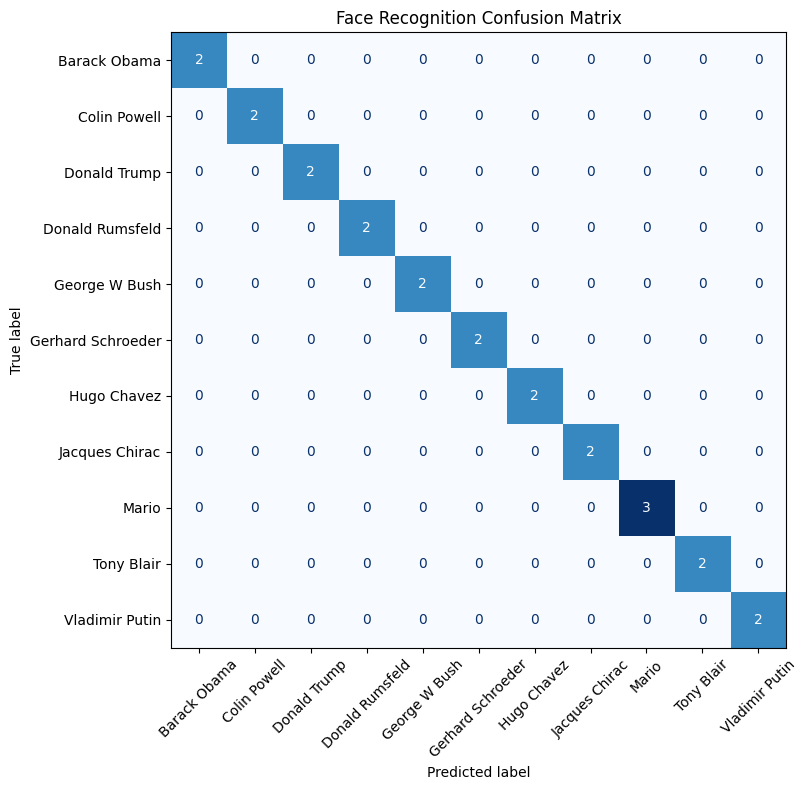

In [9]:
fig, ax = plt.subplots(figsize=(10, 8))

ConfusionMatrixDisplay.from_predictions(
    test_labels,
    test_predictions,
    labels=classifier.classes_,
    display_labels=[
        name.replace("_", " ")
        for name in classifier.classes_
    ],
    xticks_rotation=45,
    cmap="Blues",
    colorbar=False,
    ax=ax,
)

ax.set_title("Face Recognition Confusion Matrix")
plt.tight_layout()

plt.show()

## 10. Inspect every test prediction

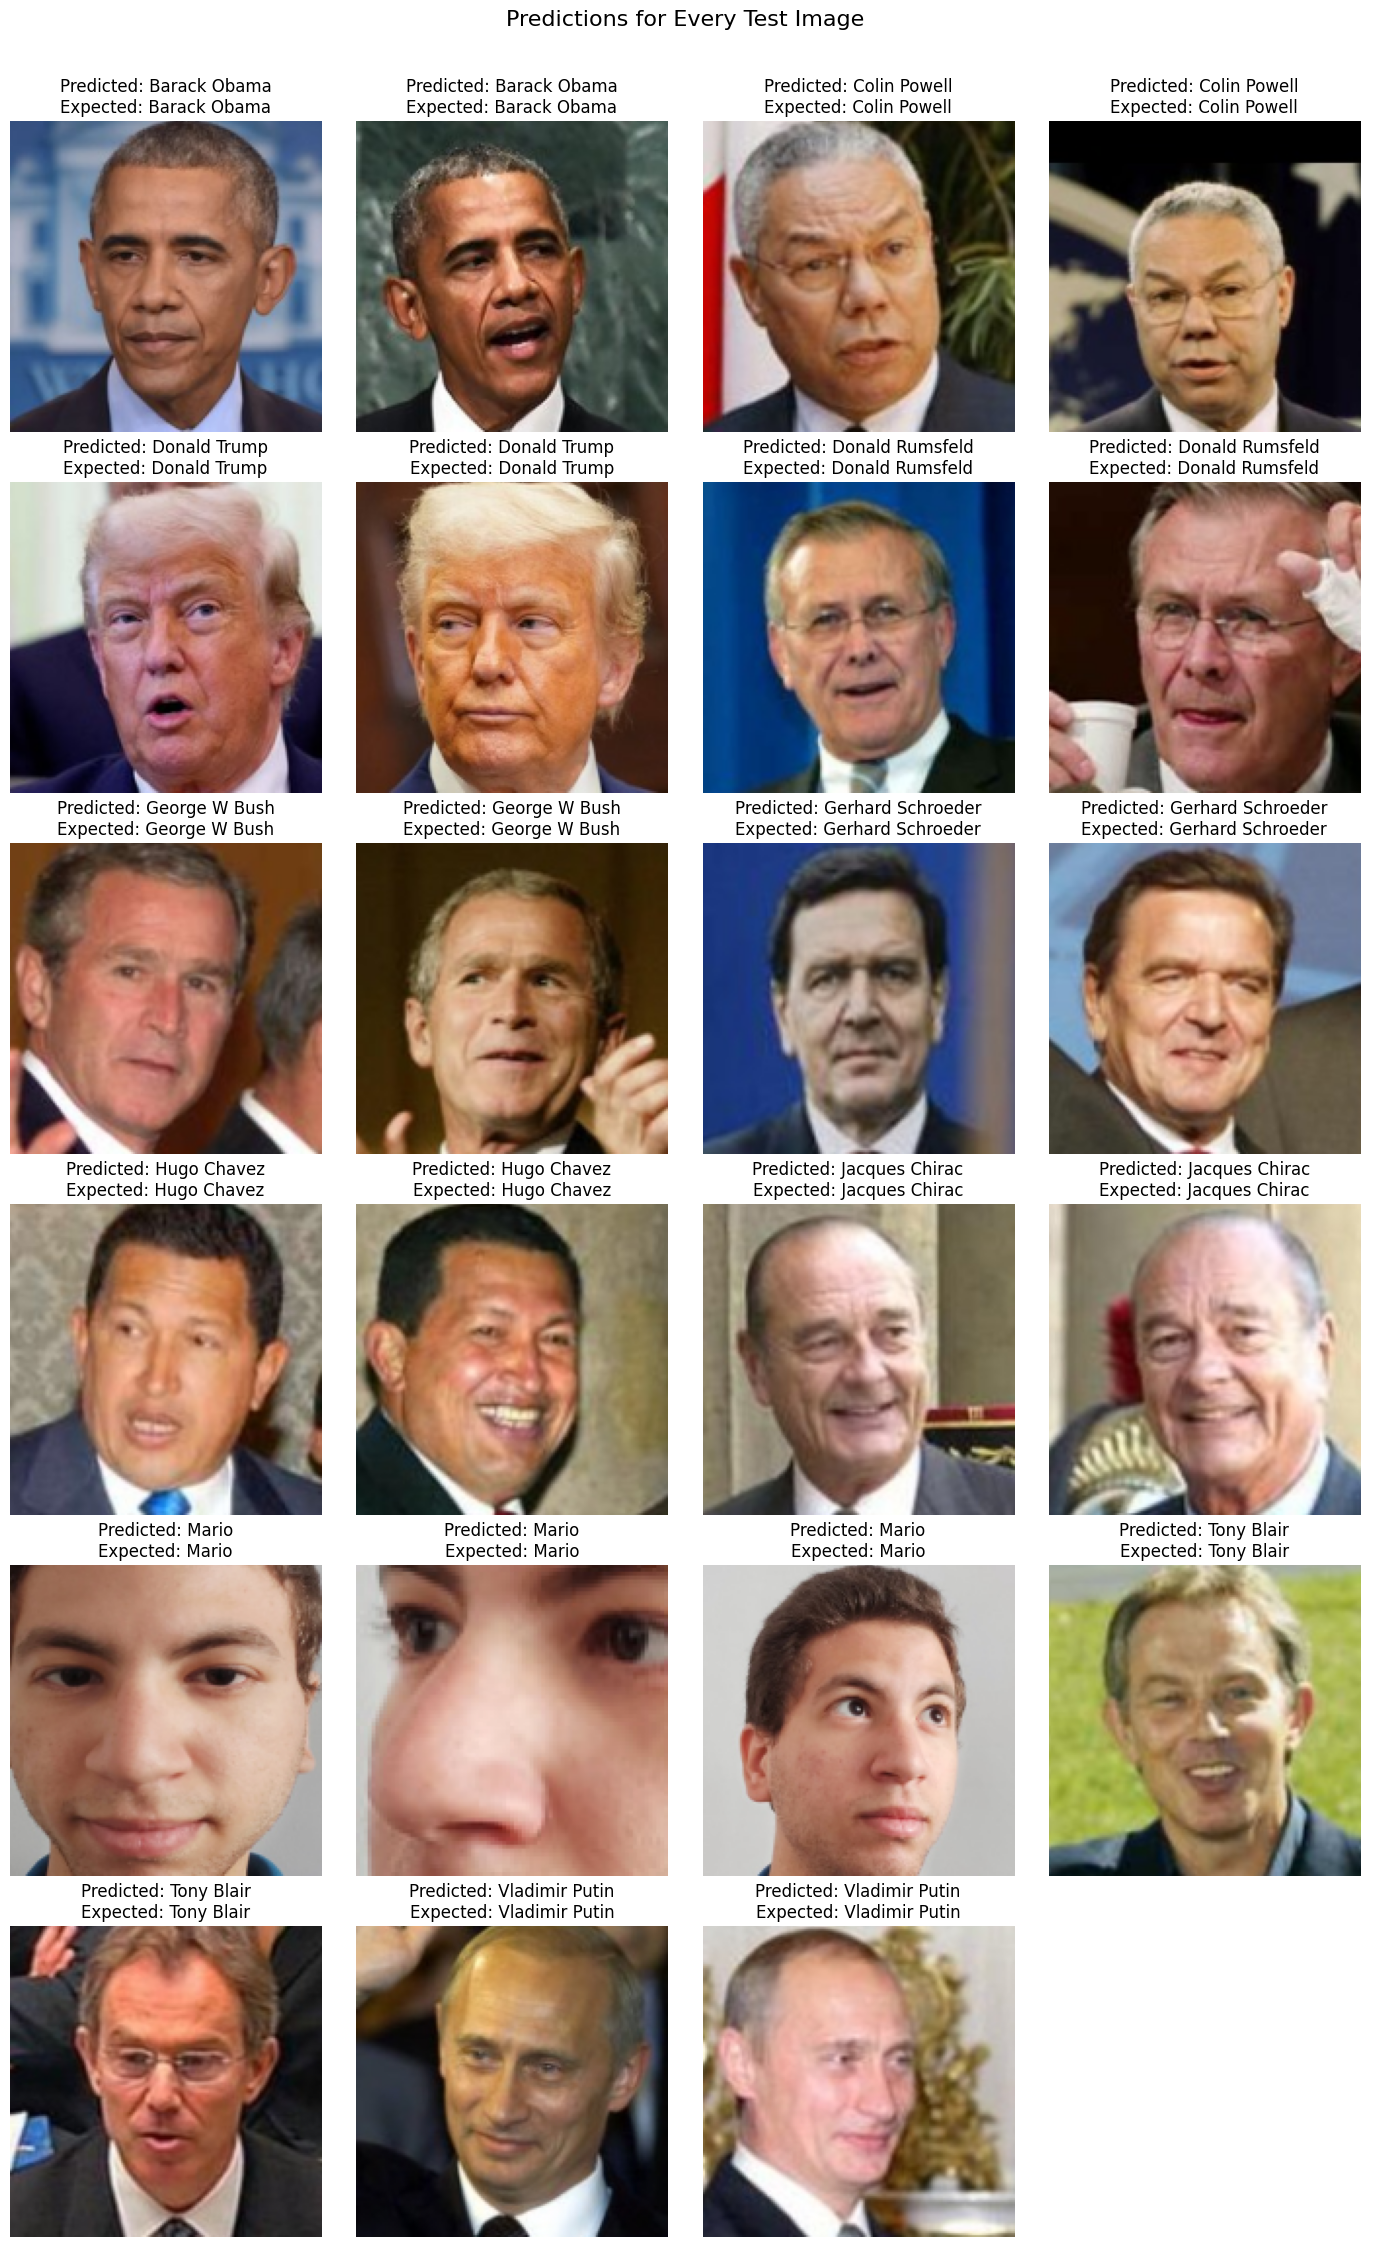

In [10]:
def plot_prediction_gallery(
    faces,
    expected_labels,
    predicted_labels,
    source_paths,
    columns=4,
):
    rows = math.ceil(len(faces) / columns)

    fig, axes = plt.subplots(
        rows,
        columns,
        figsize=(14, 3.7 * rows),
    )

    axes = np.asarray(axes).reshape(-1)

    for index, ax in enumerate(axes):
        ax.axis("off")

        if index >= len(faces):
            continue

        expected = expected_labels[index]
        predicted = predicted_labels[index]
        correct = predicted == expected

        ax.imshow(faces[index])
        ax.set_title(
            f"Predicted: {predicted.replace('_', ' ')}\n"
            f"Expected: {expected.replace('_', ' ')}",
            fontsize=12,
        )

        ax.set_xlabel(
            Path(source_paths[index]).name,
            fontsize=8,
        )

    fig.suptitle(
        "Predictions for Every Test Image",
        fontsize=16,
        y=1.01,
    )

    plt.tight_layout()
    return fig


gallery_figure = plot_prediction_gallery(
    test_faces,
    test_labels,
    test_predictions,
    test_paths,
)

plt.show()

## 11. Inspect one test image

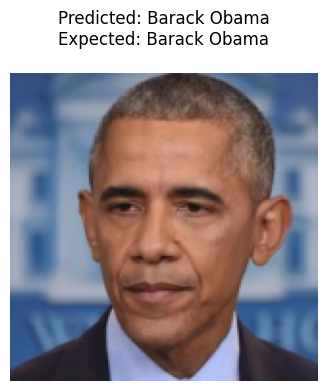

In [11]:
def recognize_test_face(index=0):
    embedding = test_embeddings[index:index + 1]

    predicted_name = classifier.predict(embedding)[0]
    expected_name = test_labels[index]

    plt.figure(figsize=(4, 4))
    plt.imshow(test_faces[index])
    plt.axis("off")
    plt.title(
        f"Predicted: {predicted_name.replace('_', ' ')}\n"
        f"Expected: {expected_name.replace('_', ' ')}\n"
    )
    plt.show()

recognize_test_face(0)

## 12. Calibrate and evaluate face verification

The verification uses Cosine similarity, which is not a probability, in this cell, a threshold is chosen through training-image pairs and not chosen manually.

In [12]:
def l2_normalize(embeddings):
    norms = np.linalg.norm(
        embeddings,
        axis=1,
        keepdims=True,
    )
    return embeddings / np.maximum(norms, 1e-8)


def build_verification_pairs(embeddings, labels):
    normalized = l2_normalize(embeddings)

    similarities = []
    same_identity = []

    for first_index in range(len(normalized)):
        for second_index in range(first_index + 1, len(normalized)):
            similarities.append(
                float(
                    np.dot(
                        normalized[first_index],
                        normalized[second_index],
                    )
                )
            )

            same_identity.append(
                labels[first_index] == labels[second_index]
            )

    return (
        np.asarray(similarities, dtype="float32"),
        np.asarray(same_identity, dtype=bool),
    )


train_pair_scores, train_pair_truth = build_verification_pairs(
    train_embeddings,
    train_labels,
)

false_positive_rates, true_positive_rates, thresholds = roc_curve(
    train_pair_truth.astype(int),
    train_pair_scores,
)

finite_mask = np.isfinite(thresholds)
finite_thresholds = thresholds[finite_mask]
youden_j = (
    true_positive_rates[finite_mask]
    - false_positive_rates[finite_mask]
)

verification_threshold = float(
    finite_thresholds[np.argmax(youden_j)]
)

test_pair_scores, test_pair_truth = build_verification_pairs(
    test_embeddings,
    test_labels,
)

test_pair_predictions = (
    test_pair_scores >= verification_threshold
)

verification_accuracy = accuracy_score(
    test_pair_truth,
    test_pair_predictions,
)

verification_balanced_accuracy = balanced_accuracy_score(
    test_pair_truth,
    test_pair_predictions,
)

true_negative, false_positive, false_negative, true_positive = confusion_matrix(
    test_pair_truth,
    test_pair_predictions,
    labels=[False, True],
).ravel()

false_acceptance_rate = (
    false_positive / (false_positive + true_negative)
    if false_positive + true_negative
    else 0.0
)

false_rejection_rate = (
    false_negative / (false_negative + true_positive)
    if false_negative + true_positive
    else 0.0
)

print(f"Selected threshold:              {verification_threshold:.4f}")
print(f"Training same-person pairs:      {train_pair_truth.sum()}")
print(f"Training different-person pairs: {(~train_pair_truth).sum()}")
print(f"Test same-person pairs:          {test_pair_truth.sum()}")
print(f"Test different-person pairs:     {(~test_pair_truth).sum()}")
print(f"Test pair accuracy:              {verification_accuracy:.3%}")
print(f"Test balanced accuracy:          {verification_balanced_accuracy:.3%}")
print(f"False acceptance rate:           {false_acceptance_rate:.3%}")
print(f"False rejection rate:            {false_rejection_rate:.3%}")

Selected threshold:              0.4273
Training same-person pairs:      308
Training different-person pairs: 3520
Test same-person pairs:          13
Test different-person pairs:     240
Test pair accuracy:              96.443%
Test balanced accuracy:          90.849%
False acceptance rate:           2.917%
False rejection rate:            15.385%


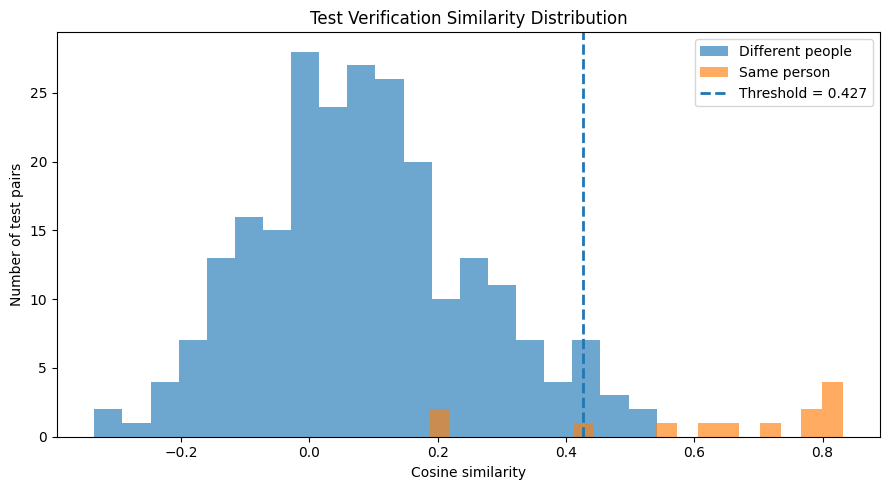

In [13]:
fig, ax = plt.subplots(figsize=(9, 5))

ax.hist(
    test_pair_scores[~test_pair_truth],
    bins=20,
    alpha=0.65,
    label="Different people",
)

ax.hist(
    test_pair_scores[test_pair_truth],
    bins=20,
    alpha=0.65,
    label="Same person",
)

ax.axvline(
    verification_threshold,
    linestyle="--",
    linewidth=2,
    label=f"Threshold = {verification_threshold:.3f}",
)

ax.set_xlabel("Cosine similarity")
ax.set_ylabel("Number of test pairs")
ax.set_title("Test Verification Similarity Distribution")
ax.legend()

plt.tight_layout()

plt.show()

## 13. Face-verification examples

Same-person example


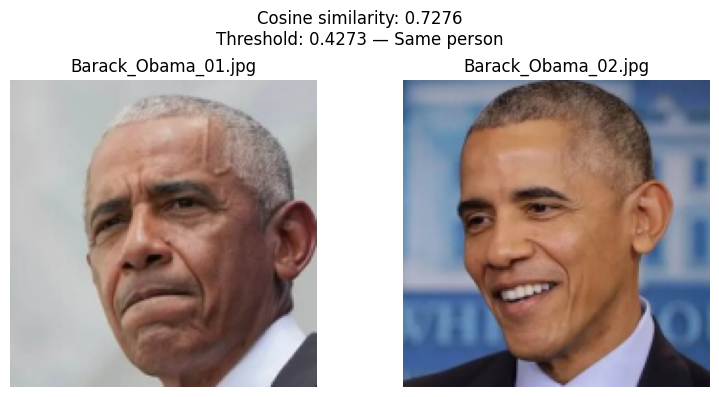


Different-person example


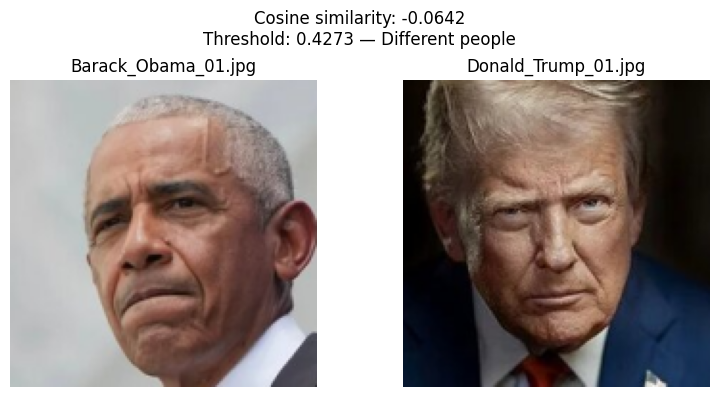

In [14]:
def face_embedding_from_path(path):
    face = prepare_face(path)
    batch = standardize_faces(
        np.expand_dims(face, axis=0)
    )

    embedding = facenet_model.predict(
        batch,
        verbose=0,
    )[0]

    return embedding / max(
        np.linalg.norm(embedding),
        1e-8,
    )


def verify_faces(
    first_path,
    second_path,
    threshold=verification_threshold,
    figure_path=None,
):
    first_embedding = face_embedding_from_path(first_path)
    second_embedding = face_embedding_from_path(second_path)

    cosine_similarity = float(
        np.dot(
            first_embedding,
            second_embedding,
        )
    )

    same_person = cosine_similarity >= threshold

    first_face = prepare_face(first_path)
    second_face = prepare_face(second_path)

    fig, axes = plt.subplots(
        1,
        2,
        figsize=(8, 4),
    )

    axes[0].imshow(first_face)
    axes[0].axis("off")
    axes[0].set_title(Path(first_path).name)

    axes[1].imshow(second_face)
    axes[1].axis("off")
    axes[1].set_title(Path(second_path).name)

    fig.suptitle(
        f"Cosine similarity: {cosine_similarity:.4f}\n"
        f"Threshold: {threshold:.4f} — "
        f"{'Same person' if same_person else 'Different people'}"
    )

    plt.tight_layout()

    if figure_path is not None:
        fig.savefig(
            figure_path,
            dpi=200,
            bbox_inches="tight",
        )

    plt.show()

same_identity_paths = class_files["Barack Obama"][:2]
different_identity_paths = [
    class_files["Barack Obama"][0],
    class_files["Donald Trump"][0],
]

print("Same-person example")
verify_faces(
    same_identity_paths[0],
    same_identity_paths[1],
)

print("\nDifferent-person example")
verify_faces(
    different_identity_paths[0],
    different_identity_paths[1],
)

## 14. Results summary

In [16]:
print(f"Identities:                     {len(class_files)}")
print(f"Images:                         {total_images}")
print(f"Training images:                {len(train_faces)}")
print(f"Held-out test images:           {len(test_faces)}")
print(f"Mean repeated CV accuracy:      {cv_scores.mean():.3%}")
print(f"Final training accuracy:        {train_accuracy:.3%}")
print(f"Final test accuracy:            {test_accuracy:.3%}")
print(f"Verification threshold:         {verification_threshold:.4f}")
print(f"Verification balanced accuracy: {verification_balanced_accuracy:.3%}")

Identities:                     11
Images:                         111
Training images:                88
Held-out test images:           23
Mean repeated CV accuracy:      98.876%
Final training accuracy:        100.000%
Final test accuracy:            100.000%
Verification threshold:         0.4273
Verification balanced accuracy: 90.849%
